<a href="https://colab.research.google.com/github/jangirsachin9619-cpu/ml7-CNN-and-evaluation-validation-techniques/blob/main/ML7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path='/content/drive/MyDrive/Food_Delivery_Time_Prediction.csv'
data=pd.read_csv(path)
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [4]:
missing_values = data.isnull().sum()
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [5]:
# Select only numeric columns to calculate their mean for imputation
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Traffic_Conditions']=le.fit_transform(data['Traffic_Conditions'])
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,2,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,2,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,2,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,1,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,0,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [8]:
data['Order_Priority']=le.fit_transform(data['Order_Priority'])
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,2,4,2,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,2,8,1,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,2,9,0,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,1,2,2,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,0,6,1,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [9]:
data = pd.get_dummies(data, columns=['Weather_Conditions', 'Order_Time', 'Vehicle_Type'], drop_first=True)
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,2,4,2,4.1,3.0,26.22,1321.10,81.54,True,False,False,False,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,2,8,1,4.5,4.2,62.61,152.21,29.02,False,False,False,False,False,True,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,9,0,3.3,3.4,48.43,1644.38,64.17,False,True,False,False,False,True,True,False
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,1,2,2,3.2,3.7,111.63,541.25,79.23,False,False,False,True,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,0,6,1,3.5,2.8,32.38,619.81,2.34,True,False,False,False,False,True,True,False


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data['Distance']=scaler.fit_transform(data['Distance'].values.reshape(-1,1))
data['Delivery_Time']=scaler.fit_transform(data['Delivery_Time'].values.reshape(-1,1))
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,2,4,2,4.1,3.0,-1.487932,1321.10,81.54,True,False,False,False,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,2,8,1,4.5,4.2,-0.264987,152.21,29.02,False,False,False,False,False,True,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,9,0,3.3,3.4,-0.741529,1644.38,64.17,False,True,False,False,False,True,True,False
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,1,2,2,3.2,3.7,1.382411,541.25,79.23,False,False,False,True,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,0,6,1,3.5,2.8,-1.280915,619.81,2.34,True,False,False,False,False,True,True,False


In [11]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

In [12]:
data[['customer_lat', 'customer_lon']] = data['Customer_Location'].str.extract(r'\(([^,]+),\s*([^)]+)\)').astype(float)
data[['restaurant_lat', 'restaurant_lon']] = data['Restaurant_Location'].str.extract(r'\(([^,]+),\s*([^)]+)\)').astype(float)

data['Haversine_Distance'] = data.apply(
    lambda row: haversine_distance(row['customer_lat'], row['customer_lon'],
                                 row['restaurant_lat'], row['restaurant_lon']),
    axis=1
)

data.drop(columns=['customer_lat', 'customer_lon', 'restaurant_lat', 'restaurant_lon'], inplace=True)
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,...,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,2,4,2,4.1,3.0,-1.487932,...,81.54,True,False,False,False,False,False,False,True,775.651198
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,2,8,1,4.5,4.2,-0.264987,...,29.02,False,False,False,False,False,True,False,True,1042.385597
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,9,0,3.3,3.4,-0.741529,...,64.17,False,True,False,False,False,True,True,False,476.220706
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,1,2,2,3.2,3.7,1.382411,...,79.23,False,False,False,True,False,False,True,False,389.912629
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,0,6,1,3.5,2.8,-1.280915,...,2.34,True,False,False,False,False,True,True,False,806.505886


In [13]:
data['Is_Rush_Hour'] = data['Order_Time_Morning'] | data['Order_Time_Evening']
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,...,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance,Is_Rush_Hour
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,2,4,2,4.1,3.0,-1.487932,...,True,False,False,False,False,False,False,True,775.651198,False
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,2,8,1,4.5,4.2,-0.264987,...,False,False,False,False,False,True,False,True,1042.385597,False
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,9,0,3.3,3.4,-0.741529,...,False,True,False,False,False,True,True,False,476.220706,False
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,1,2,2,3.2,3.7,1.382411,...,False,False,False,True,False,False,True,False,389.912629,True
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,0,6,1,3.5,2.8,-1.280915,...,True,False,False,False,False,True,True,False,806.505886,False


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Traffic_Conditions          200 non-null    int64  
 5   Delivery_Person_Experience  200 non-null    int64  
 6   Order_Priority              200 non-null    int64  
 7   Restaurant_Rating           200 non-null    float64
 8   Customer_Rating             200 non-null    float64
 9   Delivery_Time               200 non-null    float64
 10  Order_Cost                  200 non-null    float64
 11  Tip_Amount                  200 non-null    float64
 12  Weather_Conditions_Rainy    200 non-null    bool   
 13  Weather_Conditions_Snowy    200 non

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



In [16]:
median_delivery_time = data['Delivery_Time'].median()
print(f"Median Delivery Time: {median_delivery_time}")

Median Delivery Time: 0.07662482028384994


In [17]:
data['Delivery_Status'] = data['Delivery_Time'].apply(lambda x: 'Fast' if x <= median_delivery_time else 'Delayed')
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,...,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance,Is_Rush_Hour,Delivery_Status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,2,4,2,4.1,3.0,-1.487932,...,False,False,False,False,False,False,True,775.651198,False,Fast
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,2,8,1,4.5,4.2,-0.264987,...,False,False,False,False,True,False,True,1042.385597,False,Fast
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,9,0,3.3,3.4,-0.741529,...,True,False,False,False,True,True,False,476.220706,False,Fast
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,1,2,2,3.2,3.7,1.382411,...,False,False,True,False,False,True,False,389.912629,True,Delayed
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,0,6,1,3.5,2.8,-1.280915,...,False,False,False,False,True,True,False,806.505886,False,Fast


In [18]:
data.drop(columns=['Delivery_Time'], inplace=True)
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Order_Cost,...,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance,Is_Rush_Hour,Delivery_Status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,2,4,2,4.1,3.0,1321.10,...,False,False,False,False,False,False,True,775.651198,False,Fast
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,2,8,1,4.5,4.2,152.21,...,False,False,False,False,True,False,True,1042.385597,False,Fast
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,9,0,3.3,3.4,1644.38,...,True,False,False,False,True,True,False,476.220706,False,Fast
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,1,2,2,3.2,3.7,541.25,...,False,False,True,False,False,True,False,389.912629,True,Delayed
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,0,6,1,3.5,2.8,619.81,...,False,False,False,False,True,True,False,806.505886,False,Fast


In [19]:
data['Delivery_Status'] = data['Delivery_Status'].map({'Fast': 0, 'Delayed': 1})
data.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Order_Cost,...,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance,Is_Rush_Hour,Delivery_Status
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",-1.454738,2,4,2,4.1,3.0,1321.10,...,False,False,False,False,False,False,True,775.651198,False,0
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",1.439192,2,8,1,4.5,4.2,152.21,...,False,False,False,False,True,False,True,1042.385597,False,0
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",-0.666417,2,9,0,3.3,3.4,1644.38,...,True,False,False,False,True,True,False,476.220706,False,0
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",0.335835,1,2,2,3.2,3.7,541.25,...,False,False,True,False,False,True,False,389.912629,True,1
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",-0.700119,0,6,1,3.5,2.8,619.81,...,False,False,False,False,True,True,False,806.505886,False,0


In [20]:
data.drop(columns=['Order_ID', 'Customer_Location', 'Restaurant_Location'], inplace=True)
data.head()

,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance,Is_Rush_Hour,Delivery_Status
0,-1.454738,2,4,2,4.1,3.0,1321.10,81.54,True,False,False,False,False,False,False,True,775.651198,False,0
1,1.439192,2,8,1,4.5,4.2,152.21,29.02,False,False,False,False,False,True,False,True,1042.385597,False,0
2,-0.666417,2,9,0,3.3,3.4,1644.38,64.17,False,True,False,False,False,True,True,False,476.220706,False,0
3,0.335835,1,2,2,3.2,3.7,541.25,79.23,False,False,False,True,False,False,True,False,389.912629,True,1
4,-0.700119,0,6,1,3.5,2.8,619.81,2.34,True,False,False,False,False,True,True,False,806.505886,False,0


In [21]:
X = data.drop(columns=['Delivery_Status'])
y = data['Delivery_Status']
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (200, 18)
Shape of y: (200,)


In [22]:
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.head()

,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Order_Cost,Tip_Amount,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Haversine_Distance,Is_Rush_Hour
0,-1.454738,1.193481,-0.456512,1.209952,0.515500,-0.987317,0.501852,1.192403,1.583910,-0.561951,-0.600453,-0.631349,-0.492175,-0.538816,-0.725753,1.491914,0.641395,-0.960769
1,1.439192,1.193481,1.004325,-0.057013,1.085900,0.738511,-1.634294,-0.600810,-0.631349,-0.561951,-0.600453,-0.631349,-0.492175,1.855921,-0.725753,1.491914,1.632526,-0.960769
2,-0.666417,1.193481,1.369535,-1.323979,-0.625302,-0.412041,1.092646,0.599332,-0.631349,1.779513,-0.600453,-0.631349,-0.492175,1.855921,1.377879,-0.670280,-0.471227,-0.960769
3,0.335835,-0.110870,-1.186930,1.209952,-0.767902,0.019416,-0.923323,1.113532,-0.631349,-0.561951,-0.600453,1.583910,-0.492175,-0.538816,1.377879,-0.670280,-0.791930,1.040833
4,-0.700119,-1.415221,0.273907,-0.057013,-0.340101,-1.274955,-0.779755,-1.511757,1.583910,-0.561951,-0.600453,-0.631349,-0.492175,1.855921,1.377879,-0.670280,0.756045,-0.960769


In [23]:
X_reshaped = X.values.reshape(-1, 6, 3, 1)
print("Shape of X after reshaping:", X_reshaped.shape)

Shape of X after reshaping: (200, 6, 3, 1)


In [24]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(6, 3, 1)),
    layers.MaxPooling2D((2, 1)), # Adjusted pool size to prevent width dimension from becoming zero
    layers.Conv2D(64, (2, 1), activation='relu'), # Adjusted kernel size to fit input (2,1) and prevent dimensions from becoming zero
    layers.MaxPooling2D((1, 1)), # Adjusted pool size to prevent dimensions from becoming zero
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 4, 1, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1, 1, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
history = model.fit(X_reshaped, y, batch_size=32, epochs=10, validation_split=0.2)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4319 - loss: 0.7047 - val_accuracy: 0.4000 - val_loss: 0.7067
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5549 - loss: 0.6854 - val_accuracy: 0.3750 - val_loss: 0.7129
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5295 - loss: 0.6888 - val_accuracy: 0.3750 - val_loss: 0.7108
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5924 - loss: 0.6677 - val_accuracy: 0.3750 - val_loss: 0.7130
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5484 - loss: 0.6752 - val_accuracy: 0.3750 - val_loss: 0.7100
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5822 - loss: 0.6703 - val_accuracy: 0.4000 - val_loss: 0.7065
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6956 - loss: 0.6556 - val_accuracy: 0.4000 - val_loss: 0.7123
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6563 - loss: 0.6561 - val_accuracy: 0.4500 - val_loss: 0.7097


In [27]:
y_pred_proba = model.predict(X_reshaped)
print("Predictions (probabilities) generated.")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Predictions (probabilities) generated.


In [28]:
y_pred = (y_pred_proba > 0.5).astype(int)
print("Binary predictions generated.")

Binary predictions generated.


In [29]:
from sklearn.metrics import classification_report
print("classification_report imported.")

classification_report imported.


In [30]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.85      0.73       100
           1       0.77      0.51      0.61       100

    accuracy                           0.68       200
   macro avg       0.70      0.68      0.67       200
weighted avg       0.70      0.68      0.67       200



In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Instantiate Logistic Regression model
model_lr = LogisticRegression(max_iter=1000)

# Fit the model to the data
model_lr.fit(X, y)

# Make predictions
y_pred_lr = model_lr.predict(X)

# Print the classification report
print("Logistic Regression Classification Report:")
print(classification_report(y, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.60      0.62       100
           1       0.63      0.67      0.65       100

    accuracy                           0.64       200
   macro avg       0.64      0.64      0.63       200
weighted avg       0.64      0.64      0.63       200



In [35]:
!pip install keras_tuner

In [39]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()

    # Tunable number of filters for Conv2D layers
    hp_filters1 = hp.Int('filters_conv1', min_value=16, max_value=64, step=16)
    hp_filters2 = hp.Int('filters_conv2', min_value=32, max_value=128, step=32)

    # Tunable kernel sizes for Conv2D layers using hp.Choice for string representations
    hp_kernel1_str = hp.Choice('kernel_conv1', values=['2x2', '3x3'])
    hp_kernel2_str = hp.Choice('kernel_conv2', values=['1x1', '2x1'])

    # Convert string representations to tuple kernel sizes
    kernel1_tuple = tuple(map(int, hp_kernel1_str.split('x')))
    kernel2_tuple = tuple(map(int, hp_kernel2_str.split('x')))

    # Tunable activation functions
    hp_activation_conv = hp.Choice('activation_conv', values=['relu', 'tanh'])
    hp_activation_dense = hp.Choice('activation_dense', values=['relu', 'tanh'])

    # Tunable number of units for the dense layer
    hp_units_dense = hp.Int('units_dense', min_value=64, max_value=256, step=64)

    # Tunable learning rate for the optimizer
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.add(layers.Conv2D(hp_filters1,
                            kernel_size=kernel1_tuple,
                            activation=hp_activation_conv,
                            input_shape=(6, 3, 1)))
    model.add(layers.MaxPooling2D((2, 1)))
    model.add(layers.Conv2D(hp_filters2,
                            kernel_size=kernel2_tuple,
                            activation=hp_activation_conv))
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(layers.Dense(hp_units_dense, activation=hp_activation_dense))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=1,  # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to save results
    project_name='cnn_delivery_time'
)

# Start the hyperparameter search
tuner.search(X_reshaped, y, epochs=10, validation_split=0.2)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found: {best_hps.values}")

Reloading Tuner from keras_tuner_dir/cnn_delivery_time/tuner0.json
Best hyperparameters found: {'filters_conv1': 48, 'filters_conv2': 32, 'kernel_conv1': '3x3', 'kernel_conv2': '2x1', 'activation_conv': 'relu', 'activation_dense': 'tanh', 'units_dense': 192, 'learning_rate': 0.0038692738940754694}


In [36]:
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential()

    # Tunable number of filters for Conv2D layers
    hp_filters1 = hp.Int('filters_conv1', min_value=16, max_value=64, step=16)
    hp_filters2 = hp.Int('filters_conv2', min_value=32, max_value=128, step=32)

    # Tunable kernel sizes for Conv2D layers using hp.Choice for string representations
    hp_kernel1_str = hp.Choice('kernel_conv1', values=['2x2', '3x3'])
    hp_kernel2_str = hp.Choice('kernel_conv2', values=['1x1', '2x1'])

    # Convert string representations to tuple kernel sizes
    kernel1_tuple = tuple(map(int, hp_kernel1_str.split('x')))
    kernel2_tuple = tuple(map(int, hp_kernel2_str.split('x')))

    # Tunable activation functions
    hp_activation_conv = hp.Choice('activation_conv', values=['relu', 'tanh'])
    hp_activation_dense = hp.Choice('activation_dense', values=['relu', 'tanh'])

    # Tunable number of units for the dense layer
    hp_units_dense = hp.Int('units_dense', min_value=64, max_value=256, step=64)

    # Tunable learning rate for the optimizer
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.add(layers.Conv2D(hp_filters1,
                            kernel_size=kernel1_tuple,
                            activation=hp_activation_conv,
                            input_shape=(6, 3, 1)))
    model.add(layers.MaxPooling2D((2, 1)))
    model.add(layers.Conv2D(hp_filters2,
                            kernel_size=kernel2_tuple,
                            activation=hp_activation_conv))
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(layers.Dense(hp_units_dense, activation=hp_activation_dense))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=1,  # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to save results
    project_name='cnn_delivery_time'
)

# Start the hyperparameter search
tuner.search(X_reshaped, y, epochs=10, validation_split=0.2)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found: {best_hps.values}")

Trial 10 Complete [00h 00m 03s]
val_accuracy: 0.625

Best val_accuracy So Far: 0.625
Total elapsed time: 00h 01m 09s
Best hyperparameters found: {'filters_conv1': 48, 'filters_conv2': 32, 'kernel_conv1': '3x3', 'kernel_conv2': '1x1', 'activation_conv': 'tanh', 'activation_dense': 'tanh', 'units_dense': 64, 'learning_rate': 0.0036265062575473466}


In [37]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def build_optimized_cnn_model(hps):
    model = keras.Sequential()

    # Extract hyperparameters
    filters1 = hps['filters_conv1']
    filters2 = hps['filters_conv2']
    kernel1_str = hps['kernel_conv1']
    kernel2_str = hps['kernel_conv2']
    activation_conv = hps['activation_conv']
    activation_dense = hps['activation_dense']
    units_dense = hps['units_dense']
    learning_rate = hps['learning_rate']

    # Convert string kernel sizes to tuples
    kernel1_tuple = tuple(map(int, kernel1_str.split('x')))
    kernel2_tuple = tuple(map(int, kernel2_str.split('x')))

    model.add(layers.Conv2D(filters1,
                            kernel_size=kernel1_tuple,
                            activation=activation_conv,
                            input_shape=(6, 3, 1)))
    model.add(layers.MaxPooling2D((2, 1)))
    model.add(layers.Conv2D(filters2,
                            kernel_size=kernel2_tuple,
                            activation=activation_conv))
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(layers.Dense(units_dense, activation=activation_dense))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for CNN
cnn_accuracy_scores = []
cnn_precision_scores = []
cnn_recall_scores = []
cnn_f1_scores = []

# Lists to store metrics for Logistic Regression
lr_accuracy_scores = []
lr_precision_scores = []
lr_recall_scores = []
lr_f1_scores = []

print("Setup complete for K-fold cross-validation.")

# Iterate through each fold
for train_index, val_index in skf.split(X, y):
    # CNN Model
    X_train_cnn, X_val_cnn = X_reshaped[train_index], X_reshaped[val_index]
    y_train_cnn, y_val_cnn = y.iloc[train_index], y.iloc[val_index]

    cnn_model = build_optimized_cnn_model(best_hps.values)
    cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=32, verbose=0)

    y_pred_proba_cnn = cnn_model.predict(X_val_cnn, verbose=0)
    y_pred_cnn = (y_pred_proba_cnn > 0.5).astype(int)

    cnn_accuracy_scores.append(accuracy_score(y_val_cnn, y_pred_cnn))
    cnn_precision_scores.append(precision_score(y_val_cnn, y_pred_cnn))
    cnn_recall_scores.append(recall_score(y_val_cnn, y_pred_cnn))
    cnn_f1_scores.append(f1_score(y_val_cnn, y_pred_cnn))

    # Logistic Regression Model
    X_train_lr, X_val_lr = X.iloc[train_index], X.iloc[val_index]
    y_train_lr, y_val_lr = y.iloc[train_index], y.iloc[val_index]

    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train_lr, y_train_lr)

    y_pred_lr = lr_model.predict(X_val_lr)

    lr_accuracy_scores.append(accuracy_score(y_val_lr, y_pred_lr))
    lr_precision_scores.append(precision_score(y_val_lr, y_pred_lr))
    lr_recall_scores.append(recall_score(y_val_lr, y_pred_lr))
    lr_f1_scores.append(f1_score(y_val_lr, y_pred_lr))

# Calculate and print aggregated metrics
print("\n--- CNN Model Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(cnn_accuracy_scores):.4f} (+/- {np.std(cnn_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(cnn_precision_scores):.4f} (+/- {np.std(cnn_precision_scores):.4f})")
print(f"Average Recall: {np.mean(cnn_recall_scores):.4f} (+/- {np.std(cnn_recall_scores):.4f})")
print(f"Average F1-score: {np.mean(cnn_f1_scores):.4f} (+/- {np.std(cnn_f1_scores):.4f})")

print("\n--- Logistic Regression Model Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(lr_accuracy_scores):.4f} (+/- {np.std(lr_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(lr_precision_scores):.4f} (+/- {np.std(lr_precision_scores):.4f})")
print(f"Average Recall: {np.mean(lr_recall_scores):.4f} (+/- {np.std(lr_recall_scores):.4f})")
print(f"Average F1-score: {np.mean(lr_f1_scores):.4f} (+/- {np.std(lr_f1_scores):.4f})")

Setup complete for K-fold cross-validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz


--- CNN Model Cross-Validation Results ---
Average Accuracy: 0.4600 (+/- 0.0604)
Average Precision: 0.4663 (+/- 0.0543)
Average Recall: 0.5000 (+/- 0.0447)
Average F1-score: 0.4815 (+/- 0.0448)

--- Logistic Regression Model Cross-Validation Results ---
Average Accuracy: 0.5150 (+/- 0.0583)
Average Precision: 0.5133 (+/- 0.0563)
Average Recall: 0.5400 (+/- 0.0917)
Average F1-score: 0.5246 (+/- 0.0676)


In [38]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def build_optimized_cnn_model(hps):
    model = keras.Sequential()

    # Extract hyperparameters
    filters1 = hps['filters_conv1']
    filters2 = hps['filters_conv2']
    kernel1_str = hps['kernel_conv1']
    kernel2_str = hps['kernel_conv2']
    activation_conv = hps['activation_conv']
    activation_dense = hps['activation_dense']
    units_dense = hps['units_dense']
    learning_rate = hps['learning_rate']

    # Convert string kernel sizes to tuples
    kernel1_tuple = tuple(map(int, kernel1_str.split('x')))
    kernel2_tuple = tuple(map(int, kernel2_str.split('x')))

    model.add(layers.Conv2D(filters1,
                            kernel_size=kernel1_tuple,
                            activation=activation_conv,
                            input_shape=(6, 3, 1)))
    model.add(layers.MaxPooling2D((2, 1)))
    model.add(layers.Conv2D(filters2,
                            kernel_size=kernel2_tuple,
                            activation=activation_conv))
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(layers.Dense(units_dense, activation=activation_dense))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for CNN
cnn_accuracy_scores = []
cnn_precision_scores = []
cnn_recall_scores = []
cnn_f1_scores = []

# Lists to store metrics for Logistic Regression
lr_accuracy_scores = []
lr_precision_scores = []
lr_recall_scores = []
lr_f1_scores = []

print("Setup complete for K-fold cross-validation.")

# Iterate through each fold
for train_index, val_index in skf.split(X, y):
    # CNN Model
    X_train_cnn, X_val_cnn = X_reshaped[train_index], X_reshaped[val_index]
    y_train_cnn, y_val_cnn = y.iloc[train_index], y.iloc[val_index]

    cnn_model = build_optimized_cnn_model(best_hps.values)
    cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=32, verbose=0)

    y_pred_proba_cnn = cnn_model.predict(X_val_cnn, verbose=0)
    y_pred_cnn = (y_pred_proba_cnn > 0.5).astype(int)

    cnn_accuracy_scores.append(accuracy_score(y_val_cnn, y_pred_cnn))
    cnn_precision_scores.append(precision_score(y_val_cnn, y_pred_cnn))
    cnn_recall_scores.append(recall_score(y_val_cnn, y_pred_cnn))
    cnn_f1_scores.append(f1_score(y_val_cnn, y_pred_cnn))

    # Logistic Regression Model
    X_train_lr, X_val_lr = X.iloc[train_index], X.iloc[val_index]
    y_train_lr, y_val_lr = y.iloc[train_index], y.iloc[val_index]

    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train_lr, y_train_lr)

    y_pred_lr = lr_model.predict(X_val_lr)

    lr_accuracy_scores.append(accuracy_score(y_val_lr, y_pred_lr))
    lr_precision_scores.append(precision_score(y_val_lr, y_pred_lr))
    lr_recall_scores.append(recall_score(y_val_lr, y_pred_lr))
    lr_f1_scores.append(f1_score(y_val_lr, y_pred_lr))

# Calculate and print aggregated metrics
print("\n--- CNN Model Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(cnn_accuracy_scores):.4f} (+/- {np.std(cnn_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(cnn_precision_scores):.4f} (+/- {np.std(cnn_precision_scores):.4f})")
print(f"Average Recall: {np.mean(cnn_recall_scores):.4f} (+/- {np.std(cnn_recall_scores):.4f})")
print(f"Average F1-score: {np.mean(cnn_f1_scores):.4f} (+/- {np.std(cnn_f1_scores):.4f})")

print("\n--- Logistic Regression Model Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(lr_accuracy_scores):.4f} (+/- {np.std(lr_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(lr_precision_scores):.4f} (+/- {np.std(lr_precision_scores):.4f})")
print(f"Average Recall: {np.mean(lr_recall_scores):.4f} (+/- {np.std(lr_recall_scores):.4f})")
print(f"Average F1-score: {np.mean(lr_f1_scores):.4f} (+/- {np.std(lr_f1_scores):.4f})")

Setup complete for K-fold cross-validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz


--- CNN Model Cross-Validation Results ---
Average Accuracy: 0.4450 (+/- 0.0292)
Average Precision: 0.4451 (+/- 0.0316)
Average Recall: 0.4500 (+/- 0.0548)
Average F1-score: 0.4466 (+/- 0.0394)

--- Logistic Regression Model Cross-Validation Results ---
Average Accuracy: 0.5150 (+/- 0.0583)
Average Precision: 0.5133 (+/- 0.0563)
Average Recall: 0.5400 (+/- 0.0917)
Average F1-score: 0.5246 (+/- 0.0676)


In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def build_optimized_cnn_model(hps):
    model = keras.Sequential()

    # Add an Input layer explicitly to avoid UserWarning
    model.add(keras.Input(shape=(6, 3, 1)))

    # Extract hyperparameters
    filters1 = hps['filters_conv1']
    filters2 = hps['filters_conv2']
    kernel1_str = hps['kernel_conv1']
    kernel2_str = hps['kernel_conv2']
    activation_conv = hps['activation_conv']
    activation_dense = hps['activation_dense']
    units_dense = hps['units_dense']
    learning_rate = hps['learning_rate']

    # Convert string kernel sizes to tuples
    kernel1_tuple = tuple(map(int, kernel1_str.split('x')))
    kernel2_tuple = tuple(map(int, kernel2_str.split('x')))

    model.add(layers.Conv2D(filters1,
                            kernel_size=kernel1_tuple,
                            activation=activation_conv))
    model.add(layers.MaxPooling2D((2, 1)))
    model.add(layers.Conv2D(filters2,
                            kernel_size=kernel2_tuple,
                            activation=activation_conv))
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(layers.Dense(units_dense, activation=activation_dense))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for CNN
cnn_accuracy_scores = []
cnn_precision_scores = []
cnn_recall_scores = []
cnn_f1_scores = []

# Lists to store metrics for Logistic Regression
lr_accuracy_scores = []
lr_precision_scores = []
lr_recall_scores = []
lr_f1_scores = []

print("Setup complete for K-fold cross-validation.")

# Iterate through each fold
for train_index, val_index in skf.split(X, y):
    # CNN Model
    X_train_cnn, X_val_cnn = X_reshaped[train_index], X_reshaped[val_index]
    y_train_cnn, y_val_cnn = y.iloc[train_index], y.iloc[val_index]

    cnn_model = build_optimized_cnn_model(best_hps.values)
    cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=32, verbose=0)

    y_pred_proba_cnn = cnn_model.predict(X_val_cnn, verbose=0)
    y_pred_cnn = (y_pred_proba_cnn > 0.5).astype(int)

    cnn_accuracy_scores.append(accuracy_score(y_val_cnn, y_pred_cnn))
    cnn_precision_scores.append(precision_score(y_val_cnn, y_pred_cnn))
    cnn_recall_scores.append(recall_score(y_val_cnn, y_pred_cnn))
    cnn_f1_scores.append(f1_score(y_val_cnn, y_pred_cnn))

    # Logistic Regression Model
    X_train_lr, X_val_lr = X.iloc[train_index], X.iloc[val_index]
    y_train_lr, y_val_lr = y.iloc[train_index], y.iloc[val_index]

    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train_lr, y_train_lr)

    y_pred_lr = lr_model.predict(X_val_lr)

    lr_accuracy_scores.append(accuracy_score(y_val_lr, y_pred_lr))
    lr_precision_scores.append(precision_score(y_val_lr, y_pred_lr))
    lr_recall_scores.append(recall_score(y_val_lr, y_pred_lr))
    lr_f1_scores.append(f1_score(y_val_lr, y_pred_lr))

# Calculate and print aggregated metrics
print("\n--- CNN Model Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(cnn_accuracy_scores):.4f} (+/- {np.std(cnn_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(cnn_precision_scores):.4f} (+/- {np.std(cnn_precision_scores):.4f})")
print(f"Average Recall: {np.mean(cnn_recall_scores):.4f} (+/- {np.std(cnn_recall_scores):.4f})")
print(f"Average F1-score: {np.mean(cnn_f1_scores):.4f} (+/- {np.std(cnn_f1_scores):.4f})")

print("\n--- Logistic Regression Model Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(lr_accuracy_scores):.4f} (+/- {np.std(lr_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(lr_precision_scores):.4f} (+/- {np.std(lr_precision_scores):.4f})")
print(f"Average Recall: {np.mean(lr_recall_scores):.4f} (+/- {np.std(lr_recall_scores):.4f})")
print(f"Average F1-score: {np.mean(lr_f1_scores):.4f} (+/- {np.std(lr_f1_scores):.4f})")

Setup complete for K-fold cross-validation.

--- CNN Model Cross-Validation Results ---
Average Accuracy: 0.5150 (+/- 0.0644)
Average Precision: 0.5028 (+/- 0.0602)
Average Recall: 0.6000 (+/- 0.1817)
Average F1-score: 0.5413 (+/- 0.1093)

--- Logistic Regression Model Cross-Validation Results ---
Average Accuracy: 0.5150 (+/- 0.0583)
Average Precision: 0.5133 (+/- 0.0563)
Average Recall: 0.5400 (+/- 0.0917)
Average F1-score: 0.5246 (+/- 0.0676)


In [41]:
best_cnn_model = build_optimized_cnn_model(best_hps.values)
best_cnn_model.fit(X_reshaped, y, epochs=10, batch_size=32, verbose=0)

cnn_y_pred_proba = best_cnn_model.predict(X_reshaped, verbose=0)
cnn_y_pred = (cnn_y_pred_proba > 0.5).astype(int)

print("CNN model retrained and predictions generated.")

CNN model retrained and predictions generated.


Logistic Regression model retrained and predictions generated.

--- CNN Model Evaluation ---
Confusion Matrix (CNN):
 [[90 10]
 [11 89]]
ROC AUC Score (CNN): 0.9687

--- Logistic Regression Model Evaluation ---
Confusion Matrix (Logistic Regression):
 [[60 40]
 [33 67]]
ROC AUC Score (Logistic Regression): 0.6650


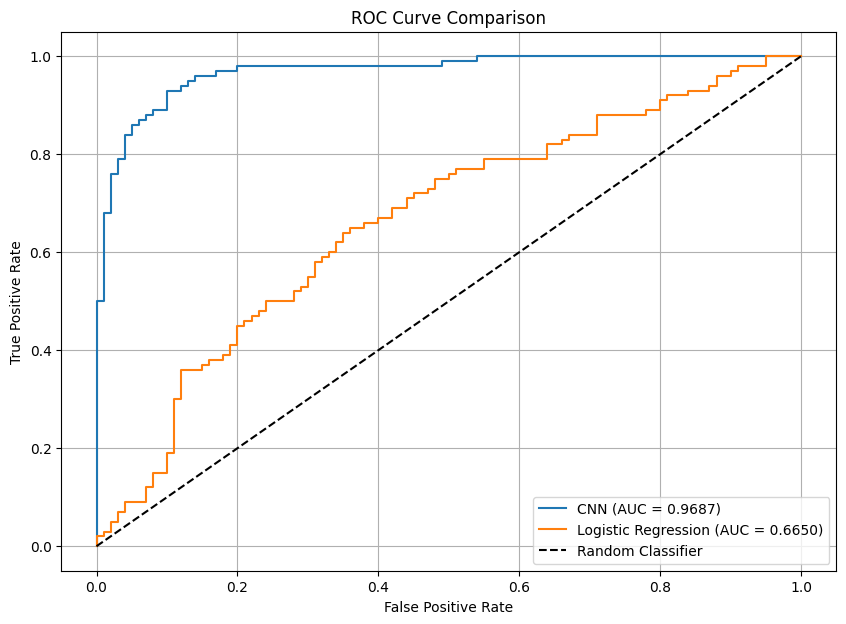

In [42]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Retrain Logistic Regression model on the entire dataset
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X, y)

# Get probability predictions for Logistic Regression
lr_y_pred_proba = lr_model.predict_proba(X)[:, 1]
lr_y_pred = (lr_y_pred_proba > 0.5).astype(int)

print("Logistic Regression model retrained and predictions generated.")

# --- Evaluation for CNN Model ---
print("\n--- CNN Model Evaluation ---")
# Confusion Matrix for CNN
cnn_cm = confusion_matrix(y, cnn_y_pred)
print("Confusion Matrix (CNN):\n", cnn_cm)

# ROC Curve for CNN
cnn_fpr, cnn_tpr, _ = roc_curve(y, cnn_y_pred_proba)
cnn_auc = roc_auc_score(y, cnn_y_pred_proba)
print(f"ROC AUC Score (CNN): {cnn_auc:.4f}")

# --- Evaluation for Logistic Regression Model ---
print("\n--- Logistic Regression Model Evaluation ---")
# Confusion Matrix for Logistic Regression
lr_cm = confusion_matrix(y, lr_y_pred)
print("Confusion Matrix (Logistic Regression):\n", lr_cm)

# ROC Curve for Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y, lr_y_pred_proba)
lr_auc = roc_auc_score(y, lr_y_pred_proba)
print(f"ROC AUC Score (Logistic Regression): {lr_auc:.4f}")

# --- Plotting ROC Curves ---
plt.figure(figsize=(10, 7))
plt.plot(cnn_fpr, cnn_tpr, label=f'CNN (AUC = {cnn_auc:.4f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()